<span style="font-size:11px">

- 모델링 : 함수 찾기
    - 집의 평수를 알면 가격을 알 수 있을까?
    - y = aX + b
    - 데이터를 잘 설명하는 직선 하나를 찾는 것이 모델링

- 손으로 숫자를 그린 이미지를 보고 숫자 7인지 1인지 맞출수 있을까?
    - 아주 복잡한 결정경계를 그린다. 경계를 그려주는 함수를 찾아내는 과정

- ANN 인공신경망
    - 단일층 : 신경망이 하나 퍼셉트론 1x1 = 뉴런 (선형계산)

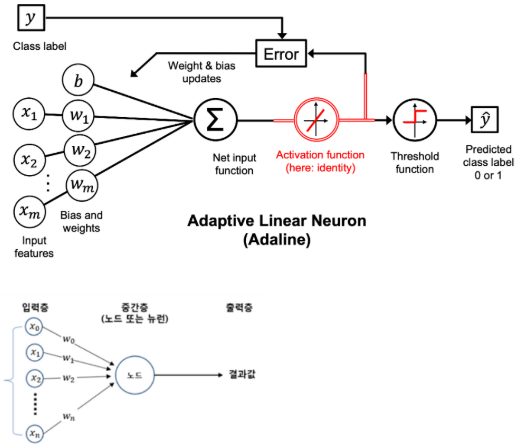

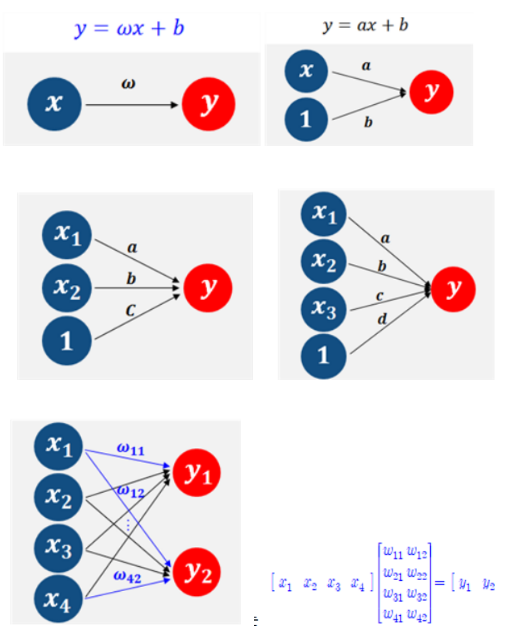



=============================================================

<span style="font-size:11px">

- 뉴런(퍼셉트론) 하나 => 하나의 직선(선형 계산)  => 복잡한 문제는 풀 수 없음 
- 활성화 함수 => 비선형성 => 딥러닝 가능 (굽은 곡선, 복잡한 경계선 ex. 이미지분류, 음성인식 등)

##### 🎯 활성화 함수 (뇌의 뉴런처럼 '이 뉴런을 켤까? 끌까?'를 결정하는 스위치)
- 활성화 함수 : 신경망이 단순한 계산기에서 뇌처럼 학습하는 존재로 진화하게 만든 핵심기술!!!

- 활성화 함수가 없을 때 : 입력값 그대로 내보냄 f(z) = z
    - 층을 여러개 쌓아도 결국 하나의 선형식(y=aX+b)으로 단순화
    - 층이 많아도 의미가 없음. (y = (W100 x .... W1)X ---->거대한 1층짜리 모델)
- 계단함수 (초기 활성화 함수)
    - if x > 0 크면 1을 출력,  x <= 0 이면 0을 출력 (스위치처럼 맞다/틀리다 정보만 알수있음)
    - 미분 불가능 (연속값X) --> 가중치 업데이트 안됨 --> 딥러닝 학습 불가능!!!!!!!!

<br> 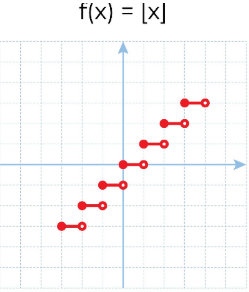


- 시그모이드 함수 (상기 함수를 개선하기위해 나옴) = Logistic 함수
    - 계단함수보다 부드럽게 반응하는 스위치 (밝기조절 스위치 같은)
    - 0~1 사이 연속적인 값이 나옴 --> 미분 가능 --> 학습(오차 역전파) 가능
    - 단점 : 양쪽끝에 도달하면 0 아니면 1에 가까워지면서 변화량이 거의 없음
<br>         가중치 업데이트가 거의 일어나지 않음.
<br>         학습량이 많아질수록 (x축 양끝으로 갈수록) 기울기가 소실..
- ReLU, tanh(-1 ~ +1), LeakyReLU
    - 시그모이드 함수의 단점 (기울기 소실) 을 해결한 새로운 활성화 함수 
    - tanh 함수  
        - 출력범위 -1 ~ +1 : 중심이 0 근처라 학습 더 잘됨. 
        - but 기울기 소실문제 여전히 존재
    - ReLU 함수  
        - 입력 0보다 크면 그대로 출력 / 0이하면 0으로 꺼버림 --> 기울기 소실 거의없음 
        - 딥러닝 학습 속도 향상 --> 요즘 딥러닝 모델 기본 활성화 함수로 사용
        - 입력이 0 이하일때 완전 죽으니, 뉴런 학습이 안됨. 

    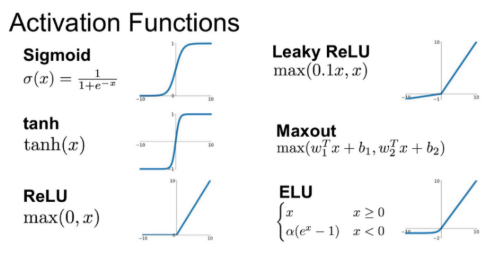


- Softmax 함수란?
    - 여러 개 출력값을 확률처럼 변환해주는 함수
    - 주로 출력층(마지막층)에서 사용
    - 출력값을 0~1로 반환하고 모든 출력의 합이 1이 되게함
    - 다중 클래스 분류(Multi-class Classification)에 최적
<br>    ex: 손글씨 숫자 0~9 → 10개의 출력, softmax 적용 후 각 숫자가 나올 확률 계산
<br>        가장 큰 값이 가장 높은 확률 → 자연스럽게 “예측 클래스” 결정 가능


#### softmax vs 시그모이드
- 정답의 종류 클래스
- softmax (여러출력값을 서로 비교해 경쟁구조로 만들기 때문에 다중 클래스 문제에 최적화)
    - 다중 클래스에서 단일 클래스만 정답 (전체 클래스 중 정답이 1개)
    - 확률 전체 클래스에 대해서 0~1 사이로 반환 : 다 합치면 1이 되는 구조ㅣ ex) 0.2  0.6  0.2
- 시그모이드
    - 여러개 이진 분류를 동시에 수행하는 방식
    - 다중 클래스 문제 중 정답이 여러개 (여러클래스가 동시에 정답) / 전체 10개 중에서 정답이 여러개일 때
    - 각 클래스 독립적으로 0~1 확률로 변환 : 합 1아님 | ex) 0.8  0.9  0.1
    - 각 클래스 예측에 독립적
<br>    ex. 영화 장르 분류 --> 액션, 코미디, SF 여러 개 가능 (각 클래스 입장에서 보면 yes no 이진분류)

==============================================

<span style="font-size:11px">

##### 다층신경망 MLP (Multi-Layer-Perceptron) : 퍼셉트론을 여러개 쌓아서 올린구조

- 단일층 퍼셉트론 (직선으로 문제해결)
    - hidden layer 없음
    - input - output 바로 연결
- 다층신경망(MLP) (곡선/복잡 문제해결) : input - hidden - output (복잡한 문제 가능)
    - input layer : 데이터가 들어오는 곳 (뉴런수 데이터의 특성 28x28 = 784)
        - 데이터를 네트워크에 전달
    - hidden layer : 입력과 출력 사이에 있는 레이어
        - 많을수록 모델이 복잡해지고, 학습 능력 증가 / 계산량이 많아짐
        - 설계하기 나름 (히든레이어 갯수는 줄어들었나 늘어났다 할수 있음.. 하이퍼 파라미터 튜닝과 유사)
    - Output layer : 모델의 최종 예측값이 나오는 층
        - 문제에 맞게 뉴런 수 맞추기
        - 뉴런 수 = 예측 클래스 수
        - 다중 클래스일 단일 정답 경우 softmax, , 이진분류 (다중 클래스 다중 정답) sigmoid

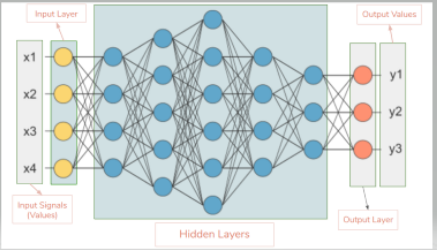

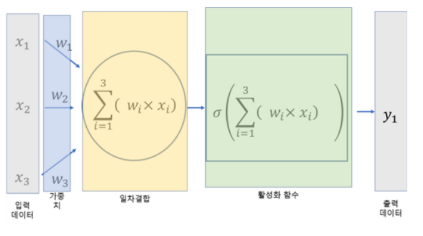


<span style="font-size:11px">

1. 머신러닝(Machine Learning)
- 정의: 데이터에서 규칙을 찾아서 예측/판단하는 알고리즘
- 대표적 모델: 선형 회귀, 로지스틱 회귀, 결정 트리, SVM 등
- 특징:
    - 사람이 특징(feature)을 설계해야 함 → 어떤 데이터가 중요한지 선택
    - 모델이 복잡하지 않은 경우 → y = wX + b (직선형)
    - 문제에 따라 비선형 모델도 가능 (트리, 커널 SVM 등)

- 머신러닝 = 꼭 직선만 그리는 게 아니라, 간단한 직선부터 복잡한 결정 경계까지 가능
- 예시
    - 집값 예측 → 선형 회귀 → y = wX + b
    - 손글씨 숫자 분류 → SVM, 결정 트리 → 비선형 경계 가능
---
2. 딥러닝(Deep Learning)
- 정의: 뇌처럼 층(layer)을 쌓은 신경망을 이용해 스스로 특징을 학습
- 특징:
    - 입력층 → 히든층 → 출력층 구조
    - 사람이 직접 특징을 설계하지 않아도, 히든 레이어에서 특징 자동 학습
    - 비선형 활성화 함수 덕분에 복잡한 패턴도 학습 가능
    - 데이터가 많을수록 성능 ↑

3. 한눈에 비교

    | 구분 | 머신러닝 | 딥러닝 |
    |------|---------|--------|
    | 입력 특징 | 사람이 설계 | 모델이 자동 학습 |
    | 모델 구조 | 단순~중간 복잡 | 다층 구조 (MLP, CNN, RNN 등) |
    | 데이터 양 | 적어도 OK | 많을수록 좋음 |
    | 표현 능력 | 제한적 (선형 또는 단순 비선형) | 매우 강함 (복잡한 비선형) |
    | 예시 | 선형 회귀, SVM | MLP, CNN, Transformer |


4. 핵심 포인트
- 머신러닝이 y = wX + b 같은 직선형만 한다는 건 단순한 경우에 해당
- 딥러닝은 층과 비선형 활성화 함수 덕분에 훨씬 복잡한 함수를 학습 가능


**비유**
- 머신러닝: 요리 재료와 레시피를 사람이 설계 → 모델이 요리
- 딥러닝: 재료만 주면, 모델이 스스로 레시피를 발견 → 더 복잡한 요리 가능

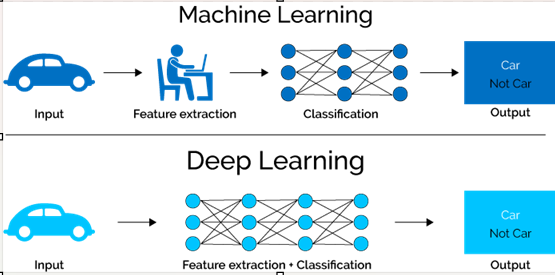

In [3]:
# %conda install tensorflow

In [4]:
# MNIST 데이터셋 로드
from sklearn.datasets import fetch_openml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# X,y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')


In [5]:
(X_train, y_train), (X_test,y_test) = tf.keras.datasets.mnist.load_data()
X_train.shape, y_train.shape


((60000, 28, 28), (60000,))

In [6]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

4


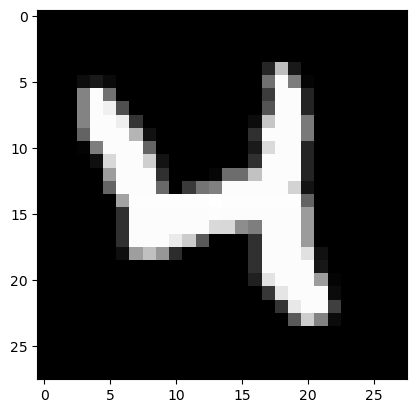

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38
  190  25   0   0   0   0   0   0   0   0]
 [  0   0   0  13  25  10   0   0   0   0   0   0   0   0   0   0   0 112
  252 125   4   0   0   0   0   0   0   0]
 [  0   0   0 132 252 113   0   0   0   0   0   0   0   0   0   0   0  61
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 240  79   0   0   0   0   0   0   0   0   0   0  84
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 252 238  52   0   0   0   0   0   0   0   

In [ ]:
print(y_train[20]) #20번째 이미지의 레이블의 값을 출력 4 : 20번째 이미지 숫자가 4란 의미
plt.imshow(X_train[20], cmap='grey') # 이미지 시각화
plt.show()
print(X_train[20])  # 20번째 이미지의 실제 픽셀값 배열 (픽셀범위 0(검은색) ~ 255(흰색))

In [ ]:
# 스케일링 표준화
# MNIST 픽셀 값은 정수범위.
# 딥러닝에서는 float로 바꿔야지 계산이 부드럽게 됨
# /255.0  --> 모든 값을 0~1 범위로 정규화
    # 큰값을 그대로 쓰면 가중치 업데이트가 너무커서 학습이 느려지거나 불안정
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

<span style="font-size:11px">

#### softmax vs 시그모이드
- 정답의 종류 클래스
- softmax (여러출력값을 서로 비교해 경쟁구조로 만들기 때문에 다중 클래스 문제에 최적화)
    - 단일 정답 다중 클래스 (전체 클래스 중 정답이 1개)
    - 확률 전체 클래스에 대해서 0~1 사이로 반환 : 다 합치면 1이 되는 구조ㅣ ex) 0.2  0.6  0.2
- 시그모이드
    - 다중 정답 다중 클래스 (여러클래스가 동시에 정답) / 전체 10개 중에서 정답이 여러개일 때
    - 각 클래스 독립적으로 0~1 확률로 변환 : 합 1아님 | ex) 0.8  0.9  0.1
    - 각 클래스 에측에 독립적

In [56]:
# 이 코드는 딥러닝으로 숫자 이미지(28×28)를 보고 0~9까지 어떤 숫자인지 맞추는 모델을 만드는 코드
# 층을 어떻게 만드냐에 따라서 모델의 성능이 달라짐
# TensorFlow 안에 포함된 Keras 라이브러리: 딥러닝 모델을 쉽게 만들 수 있게 도와주는 고수준 API예요.
# Sequential : 층을 순서대로 쌓는 모델

model = tf.keras.Sequential([ 
    # 입력층 : 28 X 28 2D ---> 784 1D : 데이터를 1차원 형태로 넣어줌
    tf.keras.layers.Flatten(input_shape = (28,28)),  
    #Faltten : 1차원으로 펼쳐주는 역할. 학습은 참여하지 않고 형태만 바꿔줌
    #Dense층이 1차원 데이터만 받으므로.
    
    # 은닉층(갯수 무한정 가능) : 128개의 뉴런을 가진 층
    tf.keras.layers.Dense(128, activation = 'relu'),
    # 각 뉴런이 입력 데이터를 받아 가중치 계산 + 활성화함수 적용을 함
    # 뉴런이 많을 수록 더 많은 패턴을 학습할수 있지만, 그만큼 계산량↑, 과적합 위험↑
    # relu : 기울기 소실 문제로 요즘은 relu를 사용 (relu : 음수는 0 양수는 그대로)
    # 은닉층 추가 가능
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(16, activation = 'relu'),
    # 은닉층이 많아질 수록 기울기가 사라지거나, 폭발할 수 있음(?)
    # 128 → 64 → 32 → 16”처럼 줄이는 건 데이터를 점점 압축하며 핵심 특징만 남기는 설계 방식
    # 분류 문제(MNIST, 감정 분석 등) → 보통 “큰→작게”
    # 생성 문제(이미지 만들기, 오토인코더 복원 등) → “작게→크게”

    # Dense : 은닉층 뿐만아니라 신경막을 구성하는 전부.. dense layer.. 단지 명칭만 입력층/히든층/출력층. 

    # 출력층
    tf.keras.layers.Dense(10,activation = 'softmax') 
    # 마지막에는 relu 안씀/ 시그모이드와 softmax 중 사용 !!!!!
    # 여기서는 softmax!! 왜? 다중 클래스 중에서 오직 정답이 하나이기 때문에! 
])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 상기 출력 해석
# Layer (type) : 모델 안에 어떤 층들이 있는지 보여줌
    # flatten_1 : 이미지를 1차원 펴는 층
    # dense_2 : 은닉층, 128개의 뉴런
    # dense_3 : 출력층, 10개의 뉴런
# Output Shape
    # 각 층을 통과한 후 데이터의 형태
    # None : 배치 크기가 정해지지 않았다 (학습할 떄 여러개를 한번에 처리가능)
    # flatten_1 --> (None, 784)  : (None, 784) : 28×28 이미지를 784개의 1차원 벡터로 변환
    # dense_2 -→ (None, 128) : 은닉층 128개 뉴런으로 변환
    # dense_3 -→ (None, 10) : 10개의 숫자 클래스 확률 출력
# param 
    # 학습 가능한 파라미터 수 (weight + bias)
    # Flatten층은 0개 파라미터 (학습하지 않으므로)

print (28*28*128+128)
print (128*10+10)

100480
1290


<!-- -----
- 은닉층 1개
- 출력층 softmax

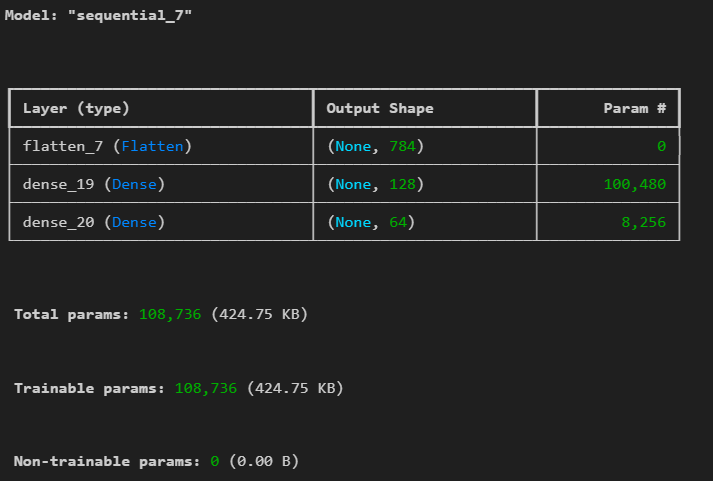 -->

======================================

In [57]:
# 딥러닝 라이브러리
model.compile (
    optimizer = 'adam',  
      # 모델이 학습할 때 가중치 (모델의 기억)를 어떻게 업데이트 할지 결정하는 방법
      #  adam 빠르고 안정적인
    loss = 'sparse_categorical_crossentropy',
      # 모델이 틀렸을 때 얼마나 틀렸는지 숫자로 알려주는 기준 (손실함수)
      # 정답 레이블(y)이 0,1,2.. 같은 정수 형태 일때 다중 클래스에 쓰는 표준 함수
      # 정답이 원-핫 벡터일 떄는 categorical_crossentropy
    metrics = ['accuracy']
      # 학습 중에 정확도(accuracy)를 계산해서 보여줘
)

In [ ]:
####### 누적되므로, 이거 실행할때는 위위에 셀에 모델 만드는것부터 실행할것
# 이미 학습된 모델에서 또 실행하면
# → 이전 가중치 위에서 추가로 20 epoch 학습
# → 이전 학습 내용 + 이번 학습 내용이 누적됨

# 예를 들어 처음 20 epoch 후 accuracy 95%,
# 다시 fit 20 epoch → 누적되어 40 epoch 학습 효과

history = model.fit(
    X_train,
    y_train,
    epochs = 20, # 전체 학습 데이터를 20번 반복해서 학습하라는 뜻 1epochs = 모든학습데이터를 한번 본것
    validation_data = (X_test, y_test), #매 epoch 끝날때 마다 데이터(검증용) 성능확인
    verbose = 1    # 학습 진행 사항을 콘솔에 출력
)



----

 - 은닉층 1개     tf.keras.layers.Dense(128, activation = 'relu')
 - 출력층으로 softmax 했을 때
    tf.keras.layers.Dense(10,activation = 'softmax') 

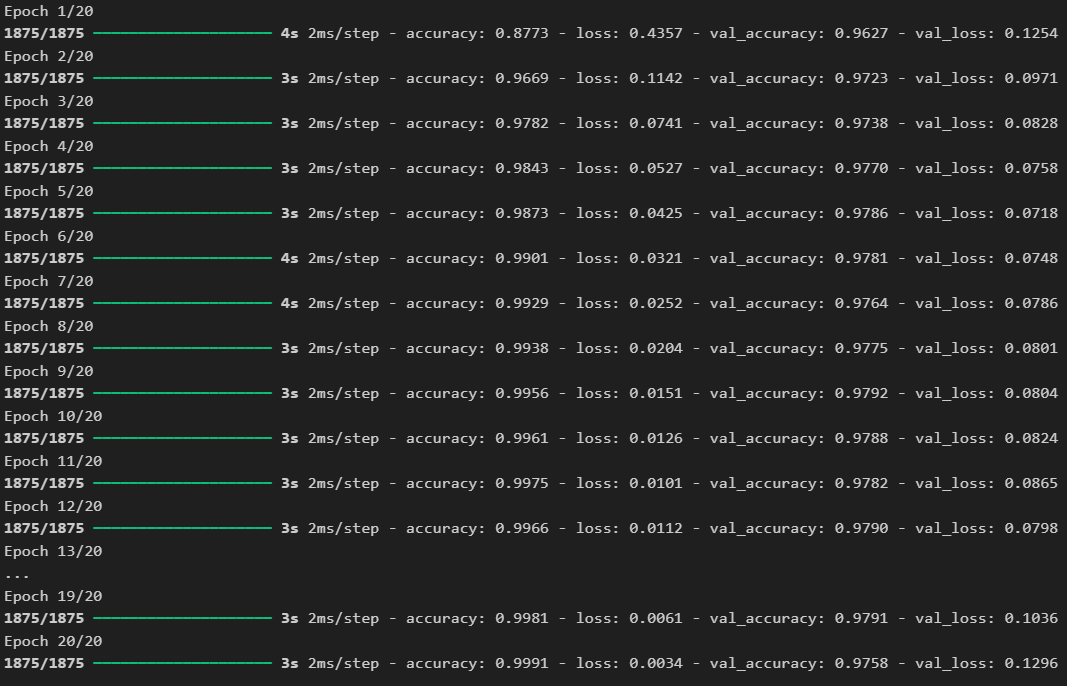

----
 은닉층 1개
 출력층으로 시그모이드 했을 때
    tf.keras.layers.Dense(10,activation = 'sigmoid') 

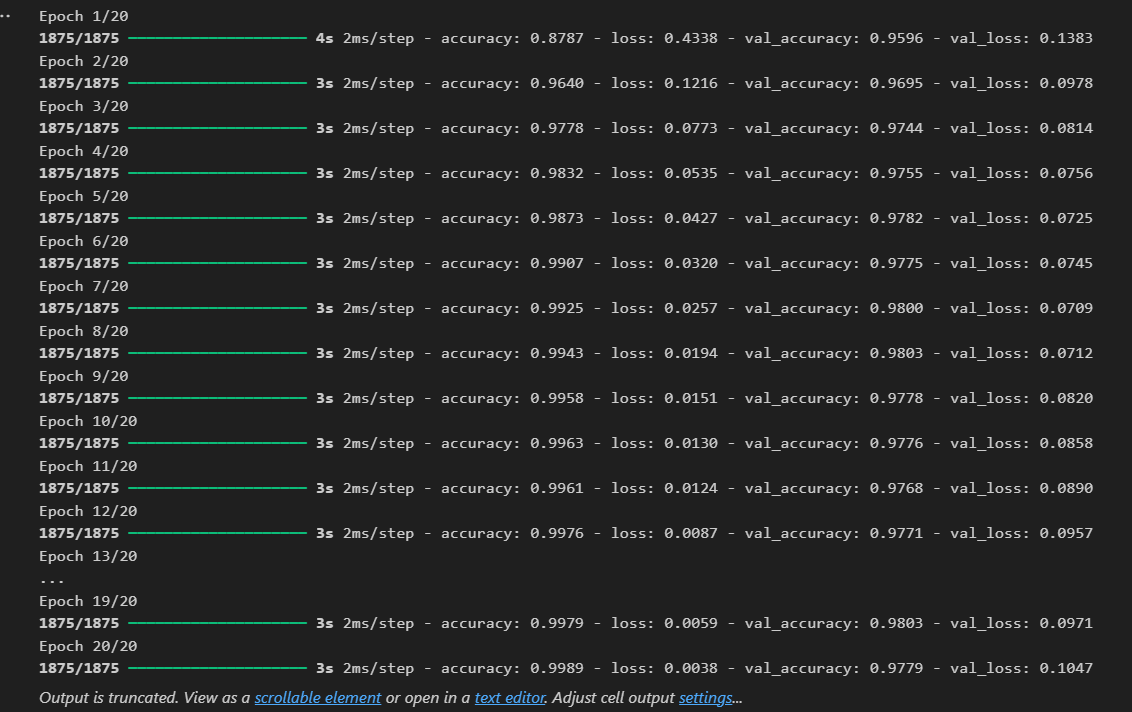

In [59]:
history.history.keys()  # history 에 어떤 key가 있는지 확인

# train : 'accuracy', 'loss'
# test : 'val_accuracy', 'val_loss'

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

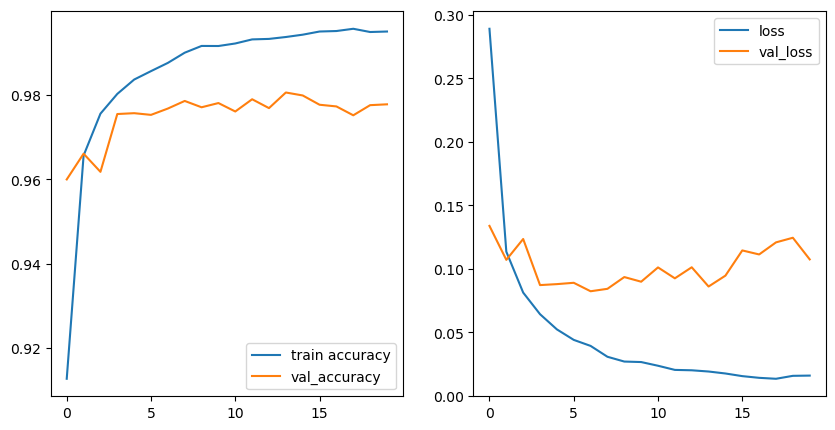

In [60]:
import matplotlib.pyplot as plt
plt.figure (figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy') 
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss') 
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

plt.show() 

#X축 : epoch 수 : 가장 좋은 accuracy 찾을 수 있음
#train은 좋아지는데 val이 안좋아지면 --> 과적합 신호
#epoch가 커질수록 val_loss가 커지므로  커지기 전의 epoch 수 찾자
# val_loss가 어느 시점부터 증가하면,그 이전 epoch이 모델이 가장 잘 일반화되는 지점일 가능성이 큼
# → 그래서 보통 early stopping(조기 종료) 같은 기법을 쓰기도 해요.

 - 은닉층 1개     tf.keras.layers.Dense(128, activation = 'relu')
 - 출력층으로 softmax 했을 때
    tf.keras.layers.Dense(10,activation = 'softmax') 

    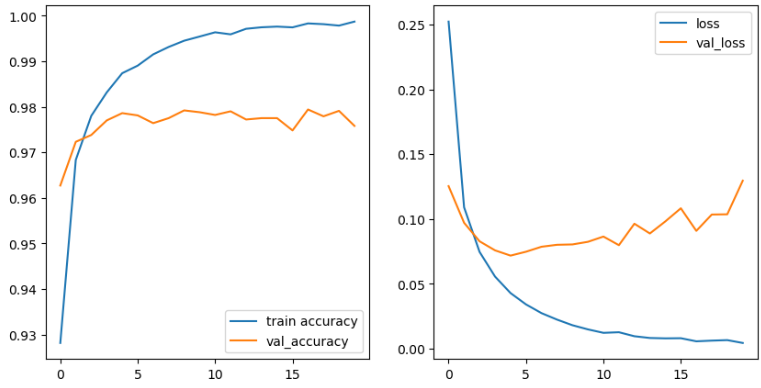

 - 은닉층 1개     tf.keras.layers.Dense(128, activation = 'relu')
 - 출력층으로 시그모이드 했을 때
    tf.keras.layers.Dense(10,activation = 'sigmoid') 

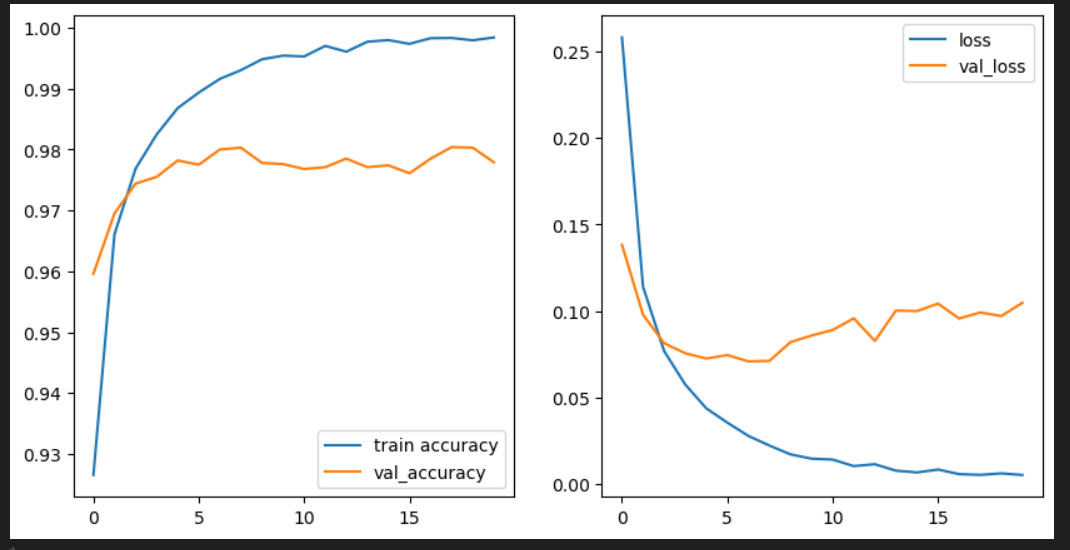

 - 은닉층 1개     tf.keras.layers.Dense(128, activation = 'relu')
 - 출력층으로 시그모이드 했을 때
    tf.keras.layers.Dense(10,activation = 'sigmoid') 

- epoch가 커질수록 val_loss가 커지므로 커지기 전의 epoch 수 찾자

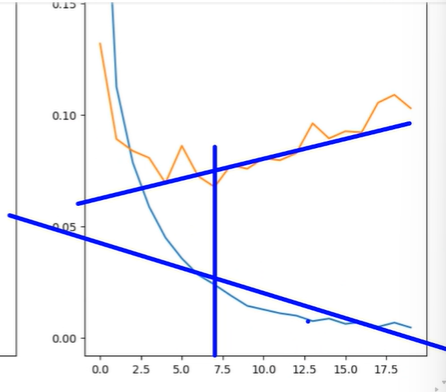

In [61]:
pred = model.predict(X_test)
print(pred.shape)  # (샘플수, 클래스수)
# 행(row)은 한 이미지에 대한 10개 클래스 (0~9)에 대한 확률을 가진 벡터
print (f'예측 {pred[10]}, \n 실제정답 {y_test[10]}')

# 출력물 해석
# (array([1.0000000e+00, 1.3799426e-20, 7.3347169e-11, 1.3306639e-17,
#         5.8070026e-21, 8.1815294e-15, 3.5673416e-14, 7.2445272e-10,
#         4.4014586e-18, 3.3630375e-08], dtype=float32),
#  np.uint8(0))
# array ==> 클래스0일 때 확률, 1일때 확률, 2일때 확률 ==> 0일때 확률이 1.0 이므로 
# y_test[10] 클래스값도 0으로 나왔으므로 정답

# 딥러닝 : 자연어 일때 머신러닝보다 훨씬 효과적
# but, 어떤것인지에 따라서 머신러닝이 딥러닝 보다 더 잘나올 수도 있음. 딥러닝이라고 무조건 좋은건 아님

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 10)
예측 [1.0000000e+00 3.3620415e-28 2.6435803e-14 1.3501881e-14 3.0483328e-20
 6.1203147e-18 5.7182617e-13 1.2134848e-16 2.1522482e-17 1.4612094e-12], 
 실제정답 0


In [62]:
model.evaluate (X_test, y_test)  # accuracy, loss 출력

# tensorflow는 sklearn과 비슷한 형태로 되어있음

# 은닉층 1개 , 출력층 softmax 일때
# 셀출력 : accuracy: 0.9732 - loss: 0.1482

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9746 - loss: 0.1378


[0.1073978915810585, 0.9778000116348267]

In [ ]:
pred
np.argmax(pred, axis=0).shape
np.argmax(pred, axis=1).shape
np.argmax(pred, axis=0)
np.argmax(pred, axis=1)


############################# axis 예제========================
# 2차원 배열(행렬): axis=0, axis=1
    # axis=0 → 세로 방향(열 기준)
    # axis=1 → 가로 방향(행 기준)

# 2차원 배열 A (4x3, 4행 3열):
A = [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9],
     [10,11,12]]

# axis=0 vs axis=1 연산
# axis=0 (세로 방향)
    # 각 열(column)마다 연산
    # 예: np.argmax(A, axis=0) → 각 열에서 가장 큰 값의 인덱스
    # 열1: [1,4,7,10] → 최대값 10 → 인덱스 3
    # 열2: [2,5,8,11] → 최대값 11 → 인덱스 3
    # 열3: [3,6,9,12] → 최대값 12 → 인덱스 3
    # 결과: [3, 3, 3]

# axis=1 (가로 방향)
    # 각 행(row)마다 연산
    # 예: np.argmax(A, axis=1) → 각 행에서 가장 큰 값의 인덱스
    # 행1: [1,2,3] → 최대값 3 → 인덱스 2
    # 행2: [4,5,6] → 최대값 6 → 인덱스 2
    # 행3: [7,8,9] → 최대값 9 → 인덱스 2
    # 행4: [10,11,12] → 최대값 12 → 인덱스 2
    # 결과: [2, 2, 2, 2]

################### 실제 본 모델링에서 #######################
# pred : 
# 각 행에 이미지1에 대해서 0~9까지 이미지 각각에 대한 확률이 기재되어있음.
# 열에는 클래스 0~ 9까지 (숫자0~9)

pred = [
 [0.01, 0.05, 0.02, 0.9, 0.01, 0.01, 0.0, 0.0, 0.0, 0.0],   # 이미지1
 [0.02, 0.1, 0.01, 0.05, 0.8, 0.01, 0.0, 0.0, 0.0, 0.01],    # 이미지2
 ...
 [ ... ]                                                      # 이미지10000
]



(10000,)

In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



 - 은닉층 1개     tf.keras.layers.Dense(128, activation = 'relu')
 - 출력층으로 softmax 했을 때
    tf.keras.layers.Dense(10,activation = 'softmax') 

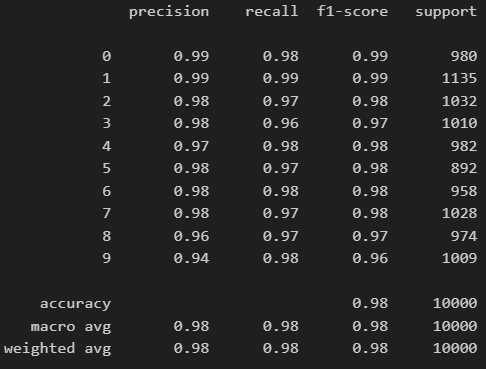